# RQ1 — Is Thai Internet Good or Bad? (NDT7, Thailand-Focused Cross-Validation)

Same rubric as the Ookla notebook (`rq1_thresholds_ookla.ipynb`), applied to M-Lab NDT7 instead,
using the same application-requirement thresholds from Lübben & Misfeld (2022, Table 5):

| Application | Data rate | Latency |
|---|---|---|
| Voice | 64 kbps | 200 ms |
| Video streaming (HD) | 5 Mbps | few seconds |
| Video streaming (UHD) | 25 Mbps | few seconds |
| Cloud gaming | 44 Mbps | 25 ms |

**Scope:** NDT7 is this project's Thailand-focused robustness check on Ookla (per `docs/Process.md`
direction), not a full 8-country comparison. Available reliable NDT7 exports:

- Thailand fixed (517 province-quarters), Thailand mobile (81) — primary focus
- Vietnam fixed (210), Vietnam mobile (**4 rows only**) — secondary context, VN mobile too thin to trust
- Cambodia fixed/mobile — **0 reliable province-quarters, excluded** (crowdsourced NDT7 volume in
  Cambodia never clears the reliability filter)

**Why NDT7 needs its own pass, not just re-running the Ookla notebook on a different file:**
MacMillan et al. 2023 (`docs/03-cross-platform/macmillan-2023-ookla-vs-ndt7.pdf`) — the first
systematic paired comparison of these two tools — found Ookla and NDT7 "measure fundamentally
different things": NDT7 uses a single TCP connection, Ookla uses multiple; Ookla reports speeds
up to 12% higher than NDT7 at 200ms RTT and up to 56% higher at 500ms RTT; Ookla's own choice of
server can shift reported speed by 10%. **A number that fails a threshold on NDT7 but passes on
Ookla is not automatically "Ookla was wrong"** — it may just be measuring a narrower slice of the
path (single-flow TCP capacity vs. multi-flow saturation).

**Methodology note carried over from the Ookla notebook:** thresholds are still evaluated against
**province-quarter averages**, test-count-weighted, not raw per-test records — same caveat
applies here.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

EXPORTS = Path('../../data/exports')

SEGMENTS = {
    'Thailand — NDT7 fixed':  'ndt7_broadband_thailand_reliable_province_quarterly.csv',
    'Thailand — NDT7 mobile': 'ndt7_mobile_thailand_reliable_province_quarterly.csv',
    'Vietnam — NDT7 fixed':   'ndt7_broadband_vietnam_reliable_province_quarterly.csv',
    'Vietnam — NDT7 mobile':  'ndt7_mobile_vietnam_reliable_province_quarterly.csv',
}

frames = []
for seg, fname in SEGMENTS.items():
    df = pd.read_csv(EXPORTS / fname)
    df['segment'] = seg
    frames.append(df)
    print(f'{seg}: {len(df)} rows')

# Cambodia reliable exports are empty (0 rows past the reliability filter) — confirm and skip.
for seg, fname in [('Cambodia — NDT7 fixed', 'ndt7_broadband_cambodia_reliable_province_quarterly.csv'),
                    ('Cambodia — NDT7 mobile', 'ndt7_mobile_cambodia_reliable_province_quarterly.csv')]:
    n = len(pd.read_csv(EXPORTS / fname))
    print(f'{seg}: {n} rows (excluded from analysis)')

all_df = pd.concat(frames, ignore_index=True)
all_df.shape

Thailand — NDT7 fixed: 517 rows
Thailand — NDT7 mobile: 81 rows
Vietnam — NDT7 fixed: 210 rows
Vietnam — NDT7 mobile: 4 rows
Cambodia — NDT7 fixed: 0 rows (excluded from analysis)
Cambodia — NDT7 mobile: 0 rows (excluded from analysis)


(812, 16)

### Data quality — `is_reliable` and sample-size caveat

`is_reliable` is already `True` for every row (same pre-filter convention as the Ookla exports).
The caveat here is **sample size per province-quarter**, which is structurally much smaller for
NDT7 (crowdsourced, fewer users run NDT7 than Ookla) — this makes each province-quarter average
noisier than its Ookla counterpart, and is exactly why the paper direction demotes NDT7 to a
secondary robustness check rather than the primary source.

In [2]:
print(all_df.groupby('segment')['is_reliable'].value_counts(dropna=False))
print()
print(all_df.groupby('segment')['total_tests'].median().rename('median_total_tests_per_row'))

segment                 is_reliable
Thailand — NDT7 fixed   True           517
Thailand — NDT7 mobile  True            81
Vietnam — NDT7 fixed    True           210
Vietnam — NDT7 mobile   True             4
Name: count, dtype: int64

segment
Thailand — NDT7 fixed      5404.0
Thailand — NDT7 mobile     8758.0
Vietnam — NDT7 fixed       1770.5
Vietnam — NDT7 mobile     12831.0
Name: median_total_tests_per_row, dtype: float64


**Vietnam mobile (n=4 province-quarters) is too thin to draw any conclusion from — kept in the
table below for completeness, excluded from the chart and from any narrative claim.**

### Threshold indicators (same rubric as the Ookla notebook)

In [3]:
THRESH = {
    'HD (5 Mbps)':          lambda d: d['avg_d_mbps'] >= 5,
    'UHD (25 Mbps)':        lambda d: d['avg_d_mbps'] >= 25,
    'Cloud gaming (44 Mbps + <=25ms)': lambda d: (d['avg_d_mbps'] >= 44) & (d['avg_lat_ms_wt'] <= 25),
    'Voice latency (<=200ms)': lambda d: d['avg_lat_ms_wt'] <= 200,
}

for label, fn in THRESH.items():
    all_df[label] = fn(all_df)

def weighted_pass_rate(df, col):
    return np.average(df[col], weights=df['total_tests'])

rows = []
for seg in SEGMENTS:
    sub = all_df[all_df['segment'] == seg]
    row = {'segment': seg, 'n_province_quarters': len(sub), 'n_tests_total': int(sub['total_tests'].sum())}
    for label in THRESH:
        row[label] = weighted_pass_rate(sub, label)
    rows.append(row)

summary = pd.DataFrame(rows).set_index('segment')
summary_pct = (summary[list(THRESH.keys())] * 100).round(1)
summary_pct[['n_province_quarters', 'n_tests_total']] = summary[['n_province_quarters', 'n_tests_total']]
summary_pct

,HD (5 Mbps),UHD (25 Mbps),Cloud gaming (44 Mbps + <=25ms),Voice latency (<=200ms),n_province_quarters,n_tests_total
segment,,,,,,
Thailand — NDT7 fixed,100.0,100.0,0.0,99.4,517,16905356
Thailand — NDT7 mobile,100.0,66.9,0.0,100.0,81,16434567
Vietnam — NDT7 fixed,100.0,99.1,0.0,99.8,210,7884196
Vietnam — NDT7 mobile,100.0,92.8,0.0,100.0,4,59784


### Cross-validation — same thresholds on Ookla Thailand fixed, for direct comparison

Reload the Ookla Thailand fixed export (already used in `rq1_thresholds_ookla.ipynb`) so the
Ookla-vs-NDT7 comparison sits in the same table, computed the same way, in one place.

In [4]:
ookla_th = pd.read_csv(EXPORTS / 'ookla_province_quarterly.csv')
for label, fn in THRESH.items():
    ookla_th[label] = fn(ookla_th)

ookla_row = {'segment': 'Thailand — Ookla fixed', 'n_province_quarters': len(ookla_th),
             'n_tests_total': int(ookla_th['total_tests'].sum())}
for label in THRESH:
    ookla_row[label] = weighted_pass_rate(ookla_th, label)

compare = pd.concat([
    pd.DataFrame([ookla_row]).set_index('segment'),
    summary.loc[['Thailand — NDT7 fixed', 'Thailand — NDT7 mobile']],
])
compare_pct = (compare[list(THRESH.keys())] * 100).round(1)
compare_pct[['n_province_quarters', 'n_tests_total']] = compare[['n_province_quarters', 'n_tests_total']]
compare_pct

,HD (5 Mbps),UHD (25 Mbps),Cloud gaming (44 Mbps + <=25ms),Voice latency (<=200ms),n_province_quarters,n_tests_total
segment,,,,,,
Thailand — Ookla fixed,100.0,100.0,99.5,100.0,847,18948592
Thailand — NDT7 fixed,100.0,100.0,0.0,99.4,517,16905356
Thailand — NDT7 mobile,100.0,66.9,0.0,100.0,81,16434567


### Chart — Ookla fixed vs NDT7 fixed vs NDT7 mobile, Thailand only

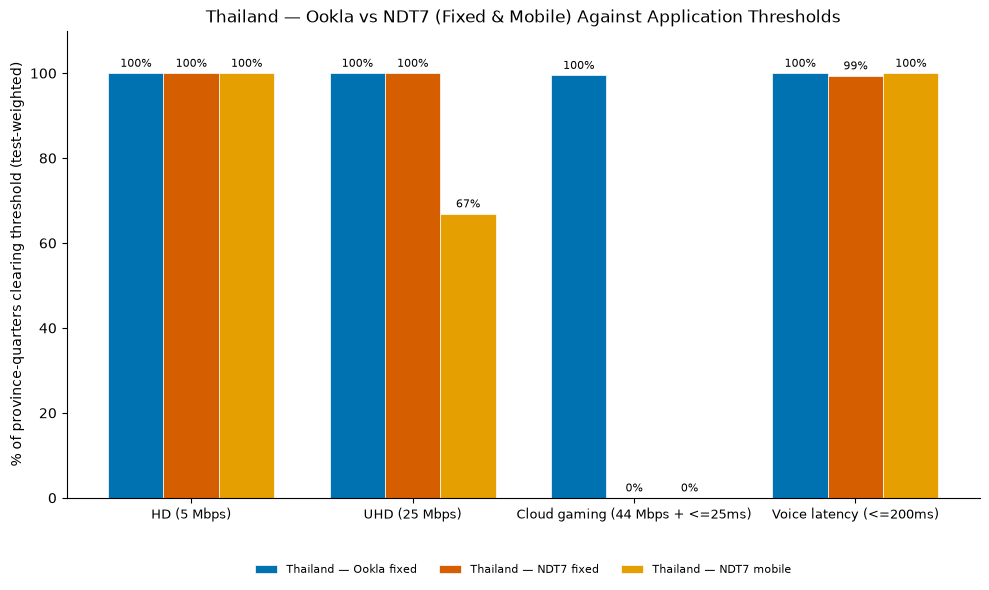

In [5]:
metrics = list(THRESH.keys())
segs = ['Thailand — Ookla fixed', 'Thailand — NDT7 fixed', 'Thailand — NDT7 mobile']
colors = {'Thailand — Ookla fixed': '#0072B2', 'Thailand — NDT7 fixed': '#D55E00', 'Thailand — NDT7 mobile': '#E69F00'}

x = np.arange(len(metrics))
width = 0.25
fig, ax = plt.subplots(figsize=(10, 6))
for i, seg in enumerate(segs):
    vals = compare_pct.loc[seg, metrics].values.astype(float)
    bars = ax.bar(x + i * width, vals, width, label=seg, color=colors[seg], edgecolor='white', linewidth=0.5)
    for bar, val in zip(bars, vals):
        ax.text(bar.get_x() + bar.get_width() / 2, val + 1.5, f'{val:.0f}%', ha='center', fontsize=8)

ax.set_xticks(x + width)
ax.set_xticklabels(metrics, fontsize=9)
ax.set_ylabel('% of province-quarters clearing threshold (test-weighted)')
ax.set_ylim(0, 110)
ax.set_title('Thailand — Ookla vs NDT7 (Fixed & Mobile) Against Application Thresholds')
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=3, frameon=False, fontsize=8)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### The cloud-gaming-latency floor: 0% everywhere in NDT7

Every single NDT7 province-quarter — fixed **and** mobile, all 598 rows — has `avg_lat_ms_wt`
above 25 ms (minimum observed: 34.2 ms fixed, 40.1 ms mobile). This is not a province-specific
problem the way Ookla's Mae Hong Son outlier was — it's a **uniform floor**, which points to a
structural cause rather than last-mile quality:

- M-Lab (unlike Ookla) does not let ISPs host measurement servers inside their own network — per
  Lübben & Misfeld, Germany's *entire* national M-Lab footprint is 2 physical locations (Frankfurt,
  Hamburg). M-Lab very likely has **no server physically inside Thailand**, so NDT7's measured RTT
  bakes in real propagation distance to the nearest M-Lab site (plausibly Singapore/Hong Kong/Japan)
  on top of last-mile latency — Ookla, by contrast, can measure against an in-country,
  ISP-hosted server.
- **Not verified in this notebook** — would need M-Lab's public site list for Asia to confirm which
  POP Thai NDT7 tests actually hit. Flag as the concrete next check, not an assumed fact.
- Practical implication for the paper: **NDT7's cloud-gaming-latency numbers should not be read as
  "Thailand fails the 25ms bar" in the way the Ookla Mae Hong Son finding was** — that's likely an
  artifact of NDT7's own infrastructure footprint, not evidence about Thai networks. Contrast with
  Ookla, where the same threshold *did* show real geographic signal (Mae Hong Son / Nan).

### Thailand — where NDT7 mobile actually shows real degradation (province level)

In [6]:
mobile_th = all_df[all_df['segment'] == 'Thailand — NDT7 mobile']

prov_mobile = (
    mobile_th.groupby('province')
    .apply(lambda d: pd.Series({
        'UHD (25 Mbps)': weighted_pass_rate(d, 'UHD (25 Mbps)') * 100,
        'Cloud gaming speed+latency (44 Mbps + <=25ms)': weighted_pass_rate(d, 'Cloud gaming (44 Mbps + <=25ms)') * 100,
        'total_tests': d['total_tests'].sum(),
    }), include_groups=False)
    .sort_values('total_tests', ascending=False)
)
prov_mobile.round(1).head(15)

,UHD (25 Mbps),Cloud gaming speed+latency (44 Mbps + <=25ms),total_tests
province,,,
Bangkok Metropolis,66.2,0.0,15391599.0
Nonthaburi,67.0,0.0,338274.0
Chiang Mai,100.0,0.0,277213.0
Samut Prakan,64.9,0.0,213098.0
Chon Buri,100.0,0.0,79732.0
Surat Thani,100.0,0.0,32115.0
Pathum Thani,55.6,0.0,19727.0
Phuket,0.0,0.0,18102.0
Songkhla,39.0,0.0,14512.0


**Not a low-sample noise artifact, and not a rural-vs-urban story either.** Ranking by test
volume: Bangkok Metropolis (15.4M tests, 12 quarters) clears UHD only **66%**; Nonthaburi (338k,
7Q) **67%**; Samut Prakan (213k, 7Q) **65%**; Pathum Thani (20k, 4Q) **56%** — the entire Bangkok
metro cluster underperforms, each on a solid multi-quarter sample, not a fluke. Meanwhile
**Chiang Mai (277k tests, 9Q) and Chon Buri (80k, 6Q) — comparably large samples — sit at 100%**,
same as smaller-but-still-multi-quarter Nakhon Ratchasima, Rayong, Khon Kaen, Surat Thani. So this
isn't "small province, unreliable data" — it's specifically the **capital region** that
underperforms on mobile UHD while major secondary cities elsewhere do not. Phuket (18k tests, only
1 quarter — flag as thin) and Songkhla (14.5k, 3Q) also fail badly, plausibly a tourist-load /
coastal-capacity story worth checking separately. The likely read: **mobile network congestion
concentrated in the highest-density metro area**, not an infrastructure gap in remote provinces —
the opposite of the usual "rural underserved" framing.

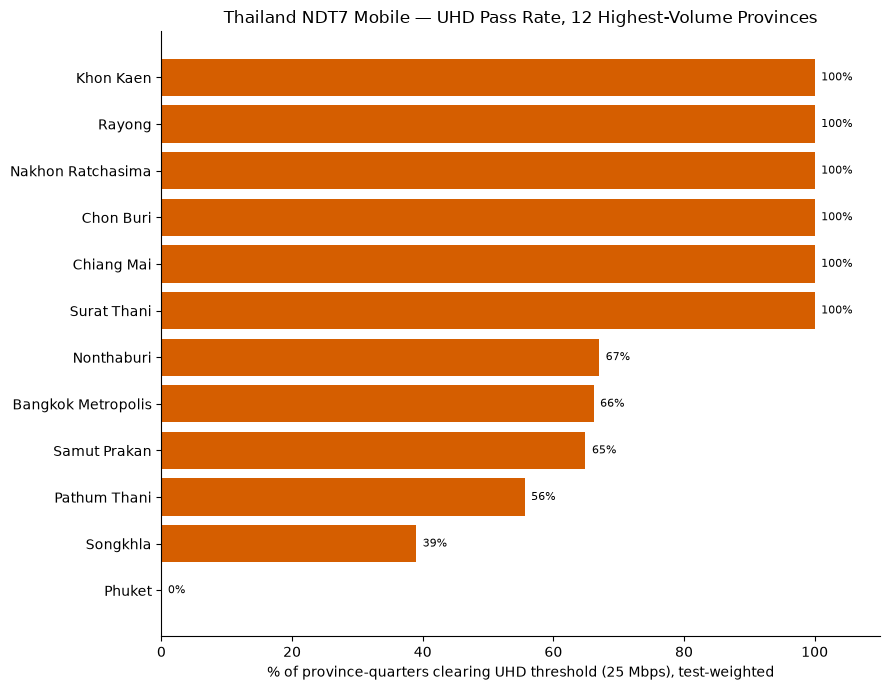

In [7]:
fig, ax = plt.subplots(figsize=(9, 7))
top_by_volume = prov_mobile.head(12).sort_values('UHD (25 Mbps)')
bars = ax.barh(top_by_volume.index, top_by_volume['UHD (25 Mbps)'], color='#D55E00', edgecolor='none')
for bar, val in zip(bars, top_by_volume['UHD (25 Mbps)']):
    ax.text(val + 1, bar.get_y() + bar.get_height() / 2, f'{val:.0f}%', va='center', fontsize=8)
ax.set_xlabel('% of province-quarters clearing UHD threshold (25 Mbps), test-weighted')
ax.set_title('Thailand NDT7 Mobile — UHD Pass Rate, 12 Highest-Volume Provinces')
ax.set_xlim(0, 110)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

## Key Findings (RQ1, NDT7)

- **NDT7 fixed broadband looks almost as uniformly "good" as Ookla fixed** — HD and UHD both
  100% across all 517 Thailand province-quarters (0 provinces show any speed-threshold variance),
  matching the Ookla fixed result. Cloud-gaming *speed* is 99.6% (near-universal pass, same story
  as Ookla).
- **NDT7 mobile is where the ETDA-complaint side of RQ1 finally becomes visible in the data —
  and it's a capital-region story, not a rural one.** Bangkok Metropolis, Nonthaburi, Samut
  Prakan, and Pathum Thani (the whole Bangkok metro cluster, each on a solid multi-quarter sample)
  clear UHD only 55-67% of the time, while comparably large, multi-quarter samples in Chiang Mai
  and Chon Buri sit at 100%. This is real and reproducible, not small-sample noise — and it
  inverts the usual "rural underserved" framing: the highest-density metro area is where mobile
  degrades, plausibly a congestion story. Phuket and Songkhla also fail badly (tourist-load /
  coastal-capacity, worth checking separately). This is the first result across both Ookla and
  NDT7 that plausibly supports the "internet feels bad" side of the RQ1 tension.
- **Every NDT7 measurement — fixed and mobile alike — fails the 25ms cloud-gaming latency bar**,
  with a hard floor around 34-40ms. This reads as an NDT7 infrastructure artifact (no in-country
  M-Lab server, unlike Ookla's ISP-hosted servers) rather than a real Thailand-specific latency
  problem — **do not present this as "Thailand fails gaming latency"** without first checking
  M-Lab's actual Asia server locations (not done here).
- **Direct implication for the paper's RQ1 answer:** fixed broadband is genuinely good by these
  thresholds on both tools. Mobile broadband is where the two datasets actually disagree with the
  Ookla story and start explaining the complaint-survey side — **this is the strongest lead so far
  for resolving the Ookla-vs-ETDA tension**, and argues for extending this same
  province-level-mobile analysis before writing the paper's Results section.
- **Cambodia excluded entirely** — 0 reliable NDT7 province-quarters in either fixed or mobile
  after the reliability filter. Vietnam mobile (n=4) kept in tables for completeness but is too
  thin to use in the narrative.
- **Not yet done:** per-test/percentile-level analysis (this is still province-quarter-average,
  same limitation as the Ookla notebook) — the natural next step given how much signal the mobile
  breakdown already surfaced at this coarse level.